In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class EmailState(TypedDict):
    email_content: str
    is_spam: bool
    classification: str
    response: str

In [3]:
def check_spam(state: EmailState):
    spam_words = ["free", "winner", "urgent", "click now"]
    is_spam = any(word in state["email_content"].lower() for word in spam_words)
    print("check_spam node executed.")
    return {"is_spam": is_spam}

def classify_email(state: EmailState):
    if state["is_spam"]:
        classification = "spam"
    elif "support" in state["email_content"].lower():
        classification = "support"
    else:
        classification = "general"
    print("classify_email node executed.")
    return {"classification": classification}

def generate_response(state: EmailState):
    if state["classification"] == "spam":
        response = "Email moved to spam folder"
    elif state["classification"] == "support":
        response = "Forwarded to support team"
    else:
        response = "Email filed in inbox"
    print("generate_response node executed.")
    return {"response": response}


In [4]:
graph_builder = StateGraph(EmailState)

graph_builder.add_node("check_spam", check_spam)
graph_builder.add_node("classify_email", classify_email)
graph_builder.add_node("generate_response", generate_response)

graph_builder.add_edge(START, "check_spam")
graph_builder.add_edge("check_spam", "classify_email")
graph_builder.add_edge("classify_email", "generate_response")
graph_builder.add_edge("generate_response", END)

In [5]:
graph = graph_builder.compile()

In [6]:
initial_state = {"email_content": "Click now to get free gifts"}
final_state = graph.invoke(initial_state)
print(final_state)

check_spam node executed.
classify_email node executed.
generate_response node executed.
{'email_content': 'Click now to get free gifts', 'is_spam': True, 'classification': 'spam', 'response': 'Email moved to spam folder'}


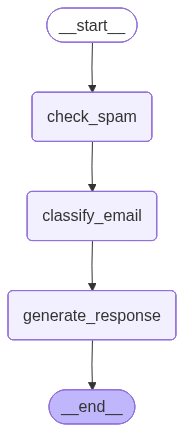

In [14]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

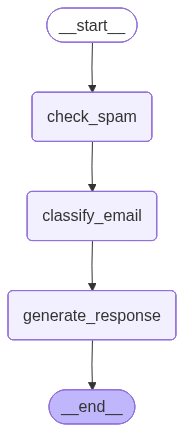

In [15]:
Image(graph.get_graph().draw_mermaid_png(), width=100)

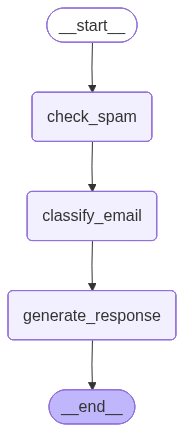

In [16]:
graph